# Preprocessing & Feature Engineering

Ce notebook prépare les données brutes et produit les fichiers CSV utilisés par le notebook de modélisation.

## Ordre du pipeline

```
df_raw
  ↓  EDA (dataset entier — aucune stat réinjectée)
  ↓  Nettoyage déterministe (capping absences, suppression G1/G2/G3)
  ↓  Feature engineering déterministe (risk_score, study_vs_social, …)
  ↓  Label encoding des binaires (mappings fixes)
  ↓  ★ TRAIN / TEST SPLIT stratifié 80/20
  ↓  OneHotEncoder.fit(X_train) → transform(train + test)
  ↓  StandardScaler.fit(X_train) → transform(train + test)
  ↓  Sauvegarde → data/processed/student_train.csv  |  data/processed/student_test.csv
```

> **Règle anti-leakage** : tout ce qui *apprend* depuis les données (OHE, scaler) est fitté **uniquement sur le train**, puis appliqué tel quel au test.


## 0. Setup

In [16]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
TEST_SIZE    = 0.2
CAP_ABSENCES = 30
PASS_THRESHOLD = 10

NB_DIR   = Path.cwd()
DATA_DIR = NB_DIR.parent / 'data' / 'processed'
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Output dir : {DATA_DIR}')


Output dir : /Users/lou-anne/Desktop/ML_proof/ml-poc-project/data/processed


## 1. Chargement

On concatène `student-mat.csv` et `student-por.csv` avec une colonne `course` pour les distinguer.  
La cible binaire `pass = (G3 ≥ 10)` est créée immédiatement — G3 sera ensuite supprimé pour éviter tout leakage.


In [17]:
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')
df_mat['course'] = 'math'
df_por['course'] = 'portuguese'

df_raw = pd.concat([df_mat, df_por], ignore_index=True)
df_raw['pass'] = (df_raw['G3'] >= PASS_THRESHOLD).astype(int)

print(f'Dataset : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
print(f'  Math      : {len(df_mat)}')
print(f'  Portugais : {len(df_por)}')
print(f'  Réussite  : {df_raw["pass"].mean()*100:.1f}%  |  Échec : {(1-df_raw["pass"].mean())*100:.1f}%')
df_raw.head(3)

Dataset : 1044 lignes × 35 colonnes
  Math      : 395
  Portugais : 649
  Réussite  : 78.0%  |  Échec : 22.0%


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,course,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,6,math,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,6,math,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,10,math,1


## 2. EDA — exploration du dataset brut

L'EDA est réalisée sur le dataset entier. Aucune statistique n'est réinjectée dans le pipeline — les décisions prises ici (capping, fusions) sont des seuils codés en dur, sans leakage.


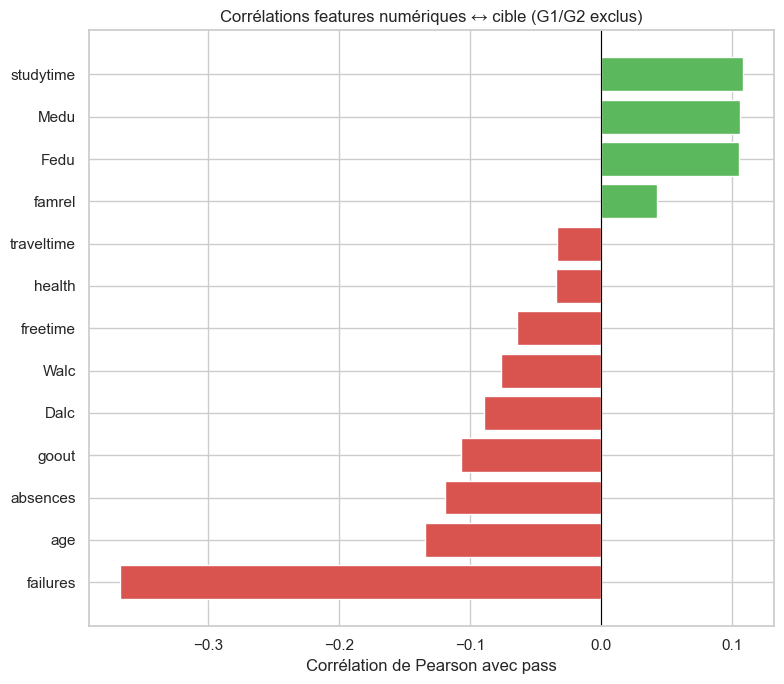

Top 5 corrélations négatives (facteurs d'échec) :
failures   -0.367
age        -0.134
absences   -0.119
goout      -0.107
Dalc       -0.090

Top 5 corrélations positives (facteurs de réussite) :
traveltime   -0.034
famrel        0.043
Fedu          0.106
Medu          0.106
studytime     0.109


In [18]:
# Corrélations des features numériques avec la cible (sans G1/G2/G3)
num_cols = df_raw.select_dtypes(include=np.number).columns.drop(['G1', 'G2', 'G3', 'pass']).tolist()
corr_target = df_raw[num_cols + ['pass']].corr()['pass'].drop('pass').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Corrélation de Pearson avec pass')
ax.set_title('Corrélations features numériques ↔ cible (G1/G2 exclus)')
plt.tight_layout()
plt.show()

print('Top 5 corrélations négatives (facteurs d\'échec) :')
print(corr_target.head(5).round(3).to_string())
print('\nTop 5 corrélations positives (facteurs de réussite) :')
print(corr_target.tail(5).round(3).to_string())


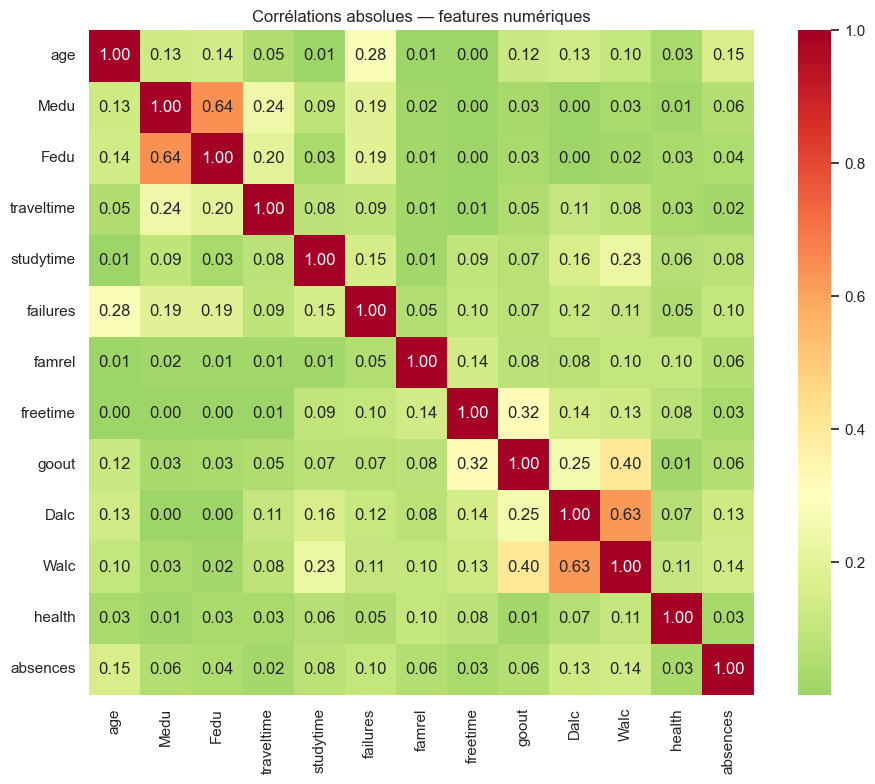

In [19]:
# Heatmap pour repérer les redondances entre features
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_raw[num_cols].corr().abs(), cmap='RdYlGn_r', center=0.3,
            annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('Corrélations absolues — features numériques')
plt.tight_layout()
plt.show()


### Observations clés

| Observation | Décision pipeline |
|---|---|
| `failures` corrélé à -0.37 avec `pass` | Pondéré ×2 dans `risk_score` |
| `Dalc` ↔ `Walc` corrélés (r > 0.6) | Fusion en `alc_total` |
| `Medu` ↔ `Fedu` corrélés (r ~ 0.6) | Fusion en `parent_edu` |
| `studytime` positif, `goout` négatif | Interaction `study_vs_social` |
| `absences` : max=75, p99≈30 | Capping à 30 (seuil fixe) |
| `G1`, `G2` corrélés > 0.8 avec G3 | **Supprimés** — non disponibles en début d'année |


## 3. Nettoyage — transformations déterministes

Opérations à seuil fixe, sans apprentissage : applicables avant le split sans leakage.

- **Valeurs manquantes** : 0 (dataset propre)
- **Doublons** : 0
- **Capping absences à 30** : seuil codé en dur (proche du p99)
- **Suppression G1, G2, G3** : G1/G2 non disponibles en début d'année ; G3 = source de la cible


In [20]:
print(f'Valeurs manquantes : {df_raw.isnull().sum().sum()}')
print(f'Doublons           : {df_raw.duplicated().sum()}')

df_clean = df_raw.copy()
df_clean['absences'] = df_clean['absences'].clip(upper=CAP_ABSENCES)
df_clean = df_clean.drop(columns=['G1', 'G2', 'G3'])

print(f'\nAvant nettoyage : {df_raw.shape}')
print(f'Après nettoyage : {df_clean.shape}')
print(f'absences — min={df_clean["absences"].min()}, max={df_clean["absences"].max()}')


Valeurs manquantes : 0
Doublons           : 0

Avant nettoyage : (1044, 35)
Après nettoyage : (1044, 32)
absences — min=0, max=30


## 4. Feature Engineering — transformations déterministes

Toutes les nouvelles features sont des fonctions déterministes des colonnes existantes (sommes, indicatrices, produits). Aucune statistique apprise → applicable avant le split.

| Feature | Construction | Justification |
|---|---|---|
| `alc_total` | `Dalc + Walc` | Réduit la redondance Dalc↔Walc (r>0.6) |
| `alc_high_risk` | `alc_total ≥ 5` | Seuil fixe — capte un comportement à risque |
| `parent_edu` | `(Medu + Fedu) / 2` | Capital éducatif moyen — évite la multicolinéarité |
| `study_vs_social` | `studytime - goout` | Arbitrage étude / vie sociale |
| `motivated_with_resources` | `higher==yes AND internet==yes` | Motivation + accès aux ressources |
| `family_capital` | `parent_edu × famrel` | Parents éduqués × qualité des relations |
| `has_support` | `schoolsup==yes OR famsup==yes` | Au moins une source de soutien |
| `digital_access` | `address==U AND internet==yes` | Bonnes conditions de travail à domicile |
| `risk_score` | combinaison pondérée | Score composite des facteurs d'échec |

**Colonnes supprimées après FE** (remplacées) : `Dalc`, `Walc`, `Medu`, `Fedu`


In [21]:
df_fe = df_clean.copy()

df_fe['alc_total']     = df_fe['Dalc'] + df_fe['Walc']
df_fe['alc_high_risk'] = (df_fe['alc_total'] >= 5).astype(int)
df_fe['parent_edu']    = (df_fe['Medu'] + df_fe['Fedu']) / 2
df_fe = df_fe.drop(columns=['Dalc', 'Walc', 'Medu', 'Fedu'])

df_fe['study_vs_social']          = df_fe['studytime'] - df_fe['goout']
df_fe['motivated_with_resources'] = ((df_fe['higher'] == 'yes') & (df_fe['internet'] == 'yes')).astype(int)
df_fe['family_capital']           = df_fe['parent_edu'] * df_fe['famrel']
df_fe['has_support']              = ((df_fe['schoolsup'] == 'yes') | (df_fe['famsup'] == 'yes')).astype(int)
df_fe['digital_access']           = ((df_fe['address'] == 'U') & (df_fe['internet'] == 'yes')).astype(int)

df_fe['risk_score'] = (
    df_fe['failures'] * 2
    + df_fe['alc_high_risk']
    + (df_fe['absences'] > 10).astype(int)
    + (df_fe['studytime'] == 1).astype(int)
    - (df_fe['higher'] == 'yes').astype(int)
).clip(lower=0)

new_feats = ['alc_total', 'alc_high_risk', 'parent_edu', 'study_vs_social',
             'motivated_with_resources', 'family_capital', 'has_support',
             'digital_access', 'risk_score']

print(f'Features créées ({len(new_feats)}) :')
for f in new_feats:
    corr = df_fe[f].corr(df_fe['pass'])
    print(f'  {f:<30} corrélation avec pass : {corr:+.3f}')

print(f'\nDataset après FE : {df_fe.shape}')


Features créées (9) :
  alc_total                      corrélation avec pass : -0.091
  alc_high_risk                  corrélation avec pass : -0.082
  parent_edu                     corrélation avec pass : +0.117
  study_vs_social                corrélation avec pass : +0.145
  motivated_with_resources       corrélation avec pass : +0.153
  family_capital                 corrélation avec pass : +0.118
  has_support                    corrélation avec pass : -0.005
  digital_access                 corrélation avec pass : +0.102
  risk_score                     corrélation avec pass : -0.370

Dataset après FE : (1044, 37)


## 5. Label encoding déterministe

Les colonnes binaires utilisent des **mappings fixes** (yes→1, no→0, F→1, U→1…).  
Rien n'est appris depuis les données → applicable avant le split.

Les colonnes nominales multi-classes (`Mjob`, `Fjob`, `reason`, `guardian`, `course`) seront traitées par OneHotEncoder **après le split**.


In [22]:
df_enc = df_fe.copy()

binary_yes_no = ['schoolsup', 'famsup', 'paid', 'activities',
                 'nursery', 'higher', 'internet', 'romantic']
for col in binary_yes_no:
    df_enc[col] = (df_enc[col] == 'yes').astype(int)

df_enc['sex']     = (df_enc['sex'] == 'F').astype(int)
df_enc['address'] = (df_enc['address'] == 'U').astype(int)
df_enc['famsize'] = (df_enc['famsize'] == 'GT3').astype(int)
df_enc['Pstatus'] = (df_enc['Pstatus'] == 'T').astype(int)
df_enc['school']  = (df_enc['school'] == 'GP').astype(int)

remaining_obj = df_enc.select_dtypes(include='object').columns.tolist()
print(f'Colonnes object restantes (→ OHE après split) : {remaining_obj}')
print(f'Dataset : {df_enc.shape}')


Colonnes object restantes (→ OHE après split) : ['Mjob', 'Fjob', 'reason', 'guardian', 'course']
Dataset : (1044, 37)


## 6. ★ Train / Test split

C'est le point de séparation. À partir d'ici, **aucune transformation qui apprend** ne touche `X_test`.

- `test_size=0.2` → 209 observations en test
- `stratify=y` → préserve le ratio 78%/22%
- `random_state=42` → reproductibilité


In [23]:
X = df_enc.drop(columns=['pass'])
y = df_enc['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f'X_train : {X_train.shape}  |  y_train pass={y_train.mean()*100:.1f}%')
print(f'X_test  : {X_test.shape}   |  y_test  pass={y_test.mean()*100:.1f}%')


X_train : (835, 36)  |  y_train pass=78.0%
X_test  : (209, 36)   |  y_test  pass=78.0%


## 7. One-Hot Encoding — fit sur train uniquement

`OneHotEncoder(handle_unknown='ignore')` : les catégories inconnues dans le test produisent une ligne nulle, sans erreur ni leakage.

Pourquoi pas `pd.get_dummies` ? Il ne mémorise pas les catégories vues au fit — risque de colonnes divergentes entre train et test.


In [24]:
NOMINAL_COLS = ['Mjob', 'Fjob', 'reason', 'guardian', 'course']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
ohe.fit(X_train[NOMINAL_COLS])

print('Catégories fittées sur le train :')
for col, cats in zip(NOMINAL_COLS, ohe.categories_):
    print(f'  {col:10s} : {list(cats)}')


Catégories fittées sur le train :
  Mjob       : ['at_home', 'health', 'other', 'services', 'teacher']
  Fjob       : ['at_home', 'health', 'other', 'services', 'teacher']
  reason     : ['course', 'home', 'other', 'reputation']
  guardian   : ['father', 'mother', 'other']
  course     : ['math', 'portuguese']


In [25]:
def apply_ohe(X_in, ohe, nominal_cols):
    X_in = X_in.copy()
    arr  = ohe.transform(X_in[nominal_cols])
    cols = ohe.get_feature_names_out(nominal_cols)
    df_ohe = pd.DataFrame(arr, columns=cols, index=X_in.index)
    return pd.concat([X_in.drop(columns=nominal_cols), df_ohe], axis=1)

X_train_enc = apply_ohe(X_train, ohe, NOMINAL_COLS)
X_test_enc  = apply_ohe(X_test,  ohe, NOMINAL_COLS)

print(f'X_train_enc : {X_train_enc.shape}')
print(f'X_test_enc  : {X_test_enc.shape}')
print(f'Colonnes identiques : {list(X_train_enc.columns) == list(X_test_enc.columns)}')


X_train_enc : (835, 50)
X_test_enc  : (209, 50)
Colonnes identiques : True


## 8. Scaling — StandardScaler fit sur train uniquement

Le scaler apprend µ et σ uniquement sur `X_train_enc`, puis transforme train et test séparément.  
Sur les modèles arborescents (RF, GB) le scaling n'a pas d'effet — on conserve néanmoins la version scalée pour la Régression Logistique.


In [26]:
scaler = StandardScaler()
scaler.fit(X_train_enc)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_enc),
    columns=X_train_enc.columns, index=X_train_enc.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_enc),
    columns=X_test_enc.columns, index=X_test_enc.index
)

print('Train après scaling :')
print(f'  mean ∈ [{X_train_scaled.mean().min():.3f}, {X_train_scaled.mean().max():.3f}]  (attendu ≈ 0)')
print(f'  std  ∈ [{X_train_scaled.std().min():.3f},  {X_train_scaled.std().max():.3f}]  (attendu ≈ 1)')
print('\nTest après scaling (valeurs ≠ 0/1 → scaler n\'a pas vu le test ✓) :')
print(f'  mean ∈ [{X_test_scaled.mean().min():.3f}, {X_test_scaled.mean().max():.3f}]')
print(f'  std  ∈ [{X_test_scaled.std().min():.3f},  {X_test_scaled.std().max():.3f}]')


Train après scaling :
  mean ∈ [-0.000, 0.000]  (attendu ≈ 0)
  std  ∈ [1.001,  1.001]  (attendu ≈ 1)

Test après scaling (valeurs ≠ 0/1 → scaler n'a pas vu le test ✓) :
  mean ∈ [-0.169, 0.173]
  std  ∈ [0.754,  1.069]


## 9. PCA — évaluation et fit sur train uniquement

La PCA est évaluée ici mais **non retenue pour la modélisation** (cf. conclusion ci-dessous).  
Elle est conservée pour référence et disponible dans `models/preprocess_pca.joblib`.


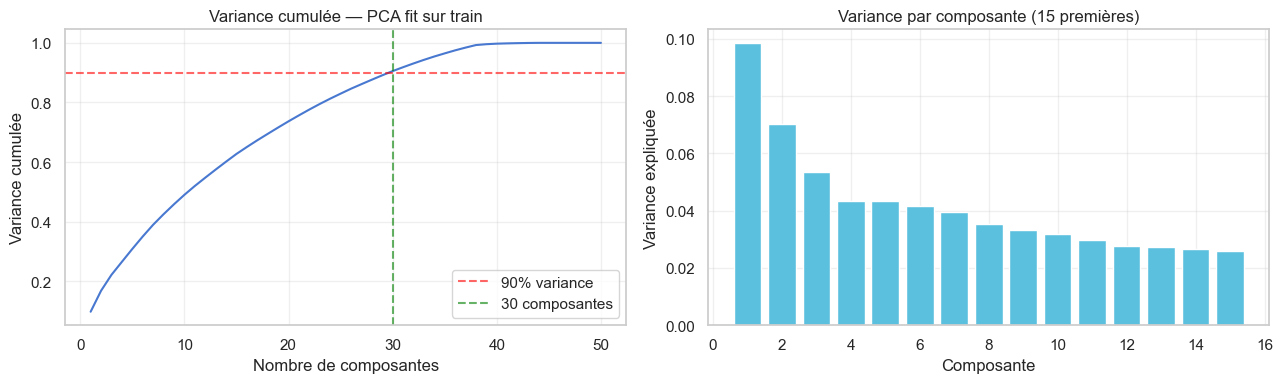

Composantes pour 90% variance : 30 / 50
Réduction dimensionnelle      : 40.0%

→ Réduction faible (40%) + dégradation des performances : PCA non retenue.


In [27]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_90 = int(np.argmax(cumvar >= 0.90) + 1)
reduction = 1 - n_comp_90 / X_train_scaled.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(cumvar)+1), cumvar, lw=1.5)
axes[0].axhline(0.90, color='red', ls='--', alpha=0.6, label='90% variance')
axes[0].axvline(n_comp_90, color='green', ls='--', alpha=0.6, label=f'{n_comp_90} composantes')
axes[0].set_xlabel('Nombre de composantes')
axes[0].set_ylabel('Variance cumulée')
axes[0].set_title('Variance cumulée — PCA fit sur train')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(1, 16), pca_full.explained_variance_ratio_[:15], color='#5bc0de')
axes[1].set_xlabel('Composante')
axes[1].set_ylabel('Variance expliquée')
axes[1].set_title('Variance par composante (15 premières)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Composantes pour 90% variance : {n_comp_90} / {X_train_scaled.shape[1]}')
print(f'Réduction dimensionnelle      : {reduction*100:.1f}%')
print(f'\n→ Réduction faible ({reduction*100:.0f}%) + dégradation des performances : PCA non retenue.')


## 10. Vérifications anti-leakage

In [28]:
assert list(X_train_enc.columns) == list(X_test_enc.columns)
print('✓ Colonnes train/test identiques après OHE')

test_mean_max = X_test_scaled.mean().abs().max()
test_std_off  = (X_test_scaled.std() - 1).abs().max()
assert test_mean_max > 1e-6
print(f'✓ Test set après scaling : |mean| max={test_mean_max:.4f} > 0  (scaler n\'a pas vu le test)')

for name, df_ in [('X_train_enc', X_train_enc), ('X_test_enc', X_test_enc),
                   ('X_train_scaled', X_train_scaled), ('X_test_scaled', X_test_scaled)]:
    assert df_.isna().sum().sum() == 0
print('✓ Aucun NaN dans les datasets transformés')

print(f'✓ Stratification — train: {y_train.mean()*100:.1f}% pass | test: {y_test.mean()*100:.1f}% pass')


✓ Colonnes train/test identiques après OHE
✓ Test set après scaling : |mean| max=0.1726 > 0  (scaler n'a pas vu le test)
✓ Aucun NaN dans les datasets transformés
✓ Stratification — train: 78.0% pass | test: 78.0% pass


## 11. Sauvegarde

Les fichiers produits sont consommés directement par `modelling.ipynb` — le notebook de modélisation ne refait **aucune transformation**.

| Fichier | Contenu | Utilisé par |
|---|---|---|
| `student_train.csv` | X_train_scaled + y_train | Régression Logistique |
| `student_test.csv` | X_test_scaled + y_test | Évaluation finale |
| `student_train_raw.csv` | X_train_enc + y_train (non scalé) | RF, Gradient Boosting |
| `student_test_raw.csv` | X_test_enc + y_test (non scalé) | RF, Gradient Boosting |


In [29]:
import joblib

def with_target(X_df, y_ser):
    out = X_df.copy()
    out['pass'] = y_ser.values
    return out

# Scalé (pour Régression Logistique)
with_target(X_train_scaled, y_train).to_csv(DATA_DIR / 'student_train.csv', index=False)
with_target(X_test_scaled,  y_test ).to_csv(DATA_DIR / 'student_test.csv',  index=False)

# Non scalé (pour RF et GB — le scaling est inutile pour les arbres)
with_target(X_train_enc, y_train).to_csv(DATA_DIR / 'student_train_raw.csv', index=False)
with_target(X_test_enc,  y_test ).to_csv(DATA_DIR / 'student_test_raw.csv',  index=False)

# Transformateurs fittés
MODELS_DIR = NB_DIR.parent / 'models'
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(ohe,    MODELS_DIR / 'preprocess_ohe.joblib')
joblib.dump(scaler, MODELS_DIR / 'preprocess_scaler.joblib')

print('Fichiers sauvegardés :')
for f in sorted(DATA_DIR.glob('student_*.csv')):
    print(f'  {f.name}  ({f.stat().st_size/1024:.1f} KB)')
print()
for f in sorted(MODELS_DIR.glob('preprocess_*.joblib')):
    print(f'  models/{f.name}')


Fichiers sauvegardés :
  student_test.csv  (200.9 KB)
  student_test_raw.csv  (22.7 KB)
  student_train.csv  (800.4 KB)
  student_train_raw.csv  (88.9 KB)

  models/preprocess_ohe.joblib
  models/preprocess_pca.joblib
  models/preprocess_scaler.joblib


## 12. Récapitulatif

In [30]:
print('=' * 65)
print('  RECAP PIPELINE')
print('=' * 65)
print(f'  Dataset brut              : {df_raw.shape[0]:>4} × {df_raw.shape[1]:>2}')
print(f'  Après nettoyage           : {df_clean.shape[0]:>4} × {df_clean.shape[1]:>2}')
print(f'  Après feature engineering : {df_fe.shape[0]:>4} × {df_fe.shape[1]:>2}')
print(f'  Après label encoding      : {df_enc.shape[0]:>4} × {df_enc.shape[1]:>2}')
print(f'  ★ Split 80/20 stratifié (random_state={RANDOM_STATE})')
print(f'  Après OHE (fit train)     : train={X_train_enc.shape}, test={X_test_enc.shape}')
print(f'  Après scaling (fit train) : train={X_train_scaled.shape}, test={X_test_scaled.shape}')
print()
print('  TRANSFORMATEURS FITTÉS SUR LE TRAIN UNIQUEMENT :')
print('    - OneHotEncoder (handle_unknown=\'ignore\')')
print('    - StandardScaler')
print()
print('  TRANSFORMATIONS DÉTERMINISTES (avant le split, sans leakage) :')
print('    - Capping absences à 30')
print('    - Suppression G1, G2, G3')
print('    - Feature engineering (sommes, indicatrices, produits, risk_score)')
print('    - Label encoding des binaires (mappings fixes)')
print()
print('  PCA : non retenue (réduction faible, dégradation des performances)')
print('=' * 65)


  RECAP PIPELINE
  Dataset brut              : 1044 × 35
  Après nettoyage           : 1044 × 32
  Après feature engineering : 1044 × 37
  Après label encoding      : 1044 × 37
  ★ Split 80/20 stratifié (random_state=42)
  Après OHE (fit train)     : train=(835, 50), test=(209, 50)
  Après scaling (fit train) : train=(835, 50), test=(209, 50)

  TRANSFORMATEURS FITTÉS SUR LE TRAIN UNIQUEMENT :
    - OneHotEncoder (handle_unknown='ignore')
    - StandardScaler

  TRANSFORMATIONS DÉTERMINISTES (avant le split, sans leakage) :
    - Capping absences à 30
    - Suppression G1, G2, G3
    - Feature engineering (sommes, indicatrices, produits, risk_score)
    - Label encoding des binaires (mappings fixes)

  PCA : non retenue (réduction faible, dégradation des performances)
